# Feature Selection

In this notebook we compile feature engineering ideas found in other notebooks and from the [Feature Engineering](https://www.kaggle.com/learn/feature-engineering) course. We then use techniques to try to select a subset of these features. In some cases, there is a scikit-learn compatible transformer which we can use to perform this feature selection, otherwise, we write our own transformers to do this. We will consider the following techniques:

1. Models w/ built-in feature selection
2. Removing multicollinear features
3. Recursive Feature Elimination (RFECV)
4. SelectKBest w/ various scoring functions
5. Permutation Importance
6. Sequential Feature Selection (SFS)

In [1]:
# Update mlxtend (for feature_groups method for SFS)
!pip install mlxtend --upgrade --no-deps

# Global Variables
DEBUG = False  # notebook runs faster if debug = True
NUM_FOLDS = 3 if DEBUG else 12
RANDOM_SEED = 153

# Imports
import numpy as np
import pandas as pd
import warnings; warnings.filterwarnings('ignore')
from functools import partial
from collections import defaultdict, Counter
from itertools import chain
from heapq import heappush

# Speedup some scikit-learn algorithms
from sklearnex import patch_sklearn
patch_sklearn()
import sklearn

# Plotting
from matplotlib import pyplot as plt
import seaborn as sns

# Correlation/Clustering
from scipy.stats import spearmanr, pearsonr
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform, pdist

# Preprocessing 
from sklearn.base import clone
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler, MinMaxScaler
from category_encoders import OneHotEncoder, OrdinalEncoder

# Feature Selection
from sklearn.inspection import permutation_importance
from mlxtend.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import SelectKBest, SelectFromModel, RFECV
from sklearn.feature_selection import mutual_info_regression, f_regression, r_regression

# Models
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV, check_cv
from sklearn.linear_model import Ridge, RidgeCV, HuberRegressor
from sklearn.linear_model import OrthogonalMatchingPursuitCV, OrthogonalMatchingPursuit
from sklearn.linear_model import Lasso, LassoCV, Lars, LarsCV
from sklearn.linear_model import LassoLars, LassoLarsCV, ElasticNet, ElasticNetCV
from sklearn.ensemble import GradientBoostingRegressor

# VIF
from sklearn.base import BaseEstimator, TransformerMixin 
from sklearn.feature_selection import SelectorMixin
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 3.9 MB/s eta 0:00:00
  Attempting uninstall: mlxtend
    Found existing installation: mlxtend 0.20.0
    Uninstalling mlxtend-0.20.0:
      Successfully uninstalled mlxtend-0.20.0


Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [2]:
# Original Data
original_train = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
original_test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv', index_col = 'Id')
submission = pd.read_csv('../input/house-prices-advanced-regression-techniques/sample_submission.csv')

# Preprocessed Data
train = pd.read_csv('../input/house-prices-ames-cleaned-dataset/new_train.csv')
test = pd.read_csv('../input/house-prices-ames-cleaned-dataset/new_test.csv', index_col = 'Id')
original_cols = list(test.columns)

# Log transform the target
target = train['SalePrice'].apply(np.log1p)

# Cross Validation Splits
skf = list(StratifiedKFold(
    n_splits = NUM_FOLDS, 
    shuffle = True, 
    random_state = RANDOM_SEED
).split(
    train[test.columns], 
    pd.cut(target, bins = 20, labels = False)
))

# 1. Feature Engineering

These features are taken from public notebooks and the Kaggle learn course. On their own, we don't know the value each feature brings to our model (if any). We will use several techniques to evaluate the feature importance in successive sections. We consider two types of models:

1. Linear Model w/ L2 Regularization (`RidgeCV`)
2. Gradient Boosting (`GradientBoostingRegressor`)

In some cases a feature selection method will benefit one model more than the other. In the case of very slow methods, we only consider a linear model which trains much faster.

In [3]:
# Indicator Features

train["HasShed"] = (train["MiscFeature"] == "Shed").astype(int)
test["HasShed"] = (test["MiscFeature"] == "Shed").astype(int)

train['MiscFeature'] = (train['MiscFeature'].notna()).astype(int)
test['MiscFeature'] = (test['MiscFeature'].notna()).astype(int)

train['HasGarage'] = (train['GarageType'].notna()).astype(int)
test['HasGarage'] = (test['GarageType'].notna()).astype(int)

train['HasPool'] = (train['PoolArea'] > 0).astype(int)
test['HasPool'] = (test['PoolArea'] > 0).astype(int)

porch_cols = ['OpenPorchSF','EnclosedPorch','3SsnPorch','ScreenPorch','WoodDeckSF']
train['HasPorch'] = (train[porch_cols].sum(axis = 1) > 0).astype(int)
test['HasPorch'] = (test[porch_cols].sum(axis = 1) > 0).astype(int)

train['HasFireplace'] = (train['Fireplaces'] > 0).astype(int)
test['HasFireplace'] = (test['Fireplaces'] > 0).astype(int)

train['HasFence'] = (train['Fence'] > 0).astype(int)
test['HasFence'] = (test['Fence'] > 0).astype(int)

train['Has2ndFloor'] = (train['2ndFlrSF'] > 0).astype(int)
test['Has2ndFloor'] = (test['2ndFlrSF'] > 0).astype(int)

train['HasBasement'] = (train['BsmtCond'] > 0).astype(int)
test['HasBasement'] = (test['BsmtCond'] > 0).astype(int)

train['Remodel'] = (train['YearRemodAdd'] != train['YearBuilt']).astype(int)
test['Remodel'] = (test['YearRemodAdd'] != test['YearBuilt']).astype(int)


# Combine counts and square footage

train['TotalSF'] = train[['TotalBsmtSF',"1stFlrSF", "2ndFlrSF"]].sum(axis = 1)
test['TotalSF'] = test[['TotalBsmtSF',"1stFlrSF", "2ndFlrSF"]].sum(axis = 1)

train['TotalBath'] = train[['FullBath','BsmtFullBath']].sum(axis = 1) + 0.5 * train[['HalfBath','BsmtHalfBath']].sum(axis = 1)
test['TotalBath'] = test[['FullBath','BsmtFullBath']].sum(axis = 1) + 0.5 * test[['HalfBath','BsmtHalfBath']].sum(axis = 1)

train['TotalPorch'] = train[porch_cols].sum(axis = 1)
test['TotalPorch'] = test[porch_cols].sum(axis = 1)

train["PorchTypes"] = train[porch_cols].gt(0.0).sum(axis=1)
test["PorchTypes"] = test[porch_cols].gt(0.0).sum(axis=1)

train['TotalLot'] = train['LotFrontage'] + train['LotArea']
test['TotalLot'] = test['LotFrontage'] + test['LotArea']

train['TotalBsmtFin'] = train['BsmtFinSF1'] + train['BsmtFinSF2']
test['TotalBsmtFin'] = test['BsmtFinSF1'] + test['BsmtFinSF2']

train["PCA_Feature1"] = train['GrLivArea'] + train['TotalBsmtSF']
test["PCA_Feature1"] = test['GrLivArea'] + test['TotalBsmtSF']

# Misc ratio and mutliplicative features

train["LivLotRatio"] = train["GrLivArea"] / train["LotArea"]
test["LivLotRatio"] = test["GrLivArea"] / test["LotArea"]

train["Spaciousness"] = (train["1stFlrSF"]+train["2ndFlrSF"]) / train["TotRmsAbvGrd"]
test["Spaciousness"] = (test["1stFlrSF"]+test["2ndFlrSF"]) / test["TotRmsAbvGrd"]

# PCA features (PCA feature engineering course) 
# Other PCA see: https://www.kaggle.com/code/muntasirphy/house-prices-top-1/notebook?scriptVersionId=103817570

train["PCA_Feature1"] = train['GrLivArea'] + train['TotalBsmtSF']
test["PCA_Feature1"] = test['GrLivArea'] + test['TotalBsmtSF']

train["PCA_Feature2"] = np.sqrt(train['YearRemodAdd'] * train['TotalBsmtSF'])
test["PCA_Feature2"] = np.sqrt(test['YearRemodAdd'] * test['TotalBsmtSF'])

train["PCA_Feature3"] = np.sqrt(train['GrLivArea'] * train['TotRmsAbvGrd'])
test["PCA_Feature3"] = np.sqrt(test['GrLivArea'] * test['TotRmsAbvGrd'])

train["PCA_Feature4"] = np.sqrt(train['GrLivArea'] * train['1stFlrSF'])
test["PCA_Feature4"] = np.sqrt(test['GrLivArea'] * test['1stFlrSF'])
    
train["PCA_Feature5"] = np.sqrt(train['GarageCars'] * train['GarageArea'])
test["PCA_Feature5"] = np.sqrt(test['GarageCars'] * test['GarageArea'])

train["PCA_Feature6"] = np.sqrt(train['GrLivArea'] * train['FullBath'])
test["PCA_Feature6"] = np.sqrt(test['GrLivArea'] * test['FullBath'])

train["PCA_Feature7"] = np.sqrt(train['GrLivArea'] * train['2ndFlrSF'])
test["PCA_Feature7"] = np.sqrt(test['GrLivArea'] * test['2ndFlrSF'])

# Age features

train['HouseAge'] = train['YrSold'] - train['YearBuilt']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']

train['Remodel_Rel'] = (train['YrSold'] - train['YearRemodAdd']) / train['HouseAge']
test['Remodel_Rel'] = (test['YrSold'] - test['YearRemodAdd']) / test['HouseAge']
train['Remodel_Rel'] = np.nan_to_num(train['Remodel_Rel'], nan = 0, posinf = 1, neginf = 0)
test['Remodel_Rel'] = np.nan_to_num(test['Remodel_Rel'], nan = 0, posinf = 1, neginf = 0)

train['Garage_Rel'] = (train['YrSold'] - train['GarageYrBlt']) / train['HouseAge']
test['Garage_Rel'] = (test['YrSold'] - test['GarageYrBlt']) / train['HouseAge']
train['Garage_Rel'] = np.nan_to_num(train['Garage_Rel'], nan = 0, posinf = 1, neginf = 0)
test['Garage_Rel'] = np.nan_to_num(test['Garage_Rel'], nan = 0, posinf = 1, neginf = 0)


# Multiplicative interactions

train['OverallGrade'] = np.sqrt(train['OverallQual'] * train['OverallCond'])
test['OverallGrade'] = np.sqrt(test['OverallQual'] * test['OverallCond'])

train['ExterGrade'] = np.sqrt(train['ExterQual'] * train['ExterCond'])
test['ExterGrade'] = np.sqrt(test['ExterQual'] * test['ExterCond'])

train['BsmtGrade'] = np.sqrt(train['BsmtQual'] * train['BsmtCond'])
test['BsmtGrade'] = np.sqrt(test['BsmtQual'] * test['BsmtCond'])

train['GarageGrade'] = np.sqrt(train['GarageQual'] * train['GarageCond'])
test['GarageGrade'] = np.sqrt(test['GarageQual'] * test['GarageCond'])

train['MiscGrade'] = np.sqrt(train['KitchenQual'] * train['HeatingQC'])
test['MiscGrade'] = np.sqrt(test['KitchenQual'] * test['HeatingQC'])

# Other additive interactions

train['OverallSum'] = train[['OverallQual','OverallCond']].sum(axis = 1)
test['OverallSum'] = test[['OverallQual','OverallCond']].sum(axis = 1)

train['ExterSum'] = train[['ExterQual','ExterCond']].sum(axis = 1)
test['ExterSum'] = test[['ExterQual','ExterCond']].sum(axis = 1)

train['BsmtFinTypeSum'] = train[['BsmtFinType1','BsmtFinType2']].sum(axis = 1)
test['BsmtFinTypeSum'] = test[['BsmtFinType1','BsmtFinType2']].sum(axis = 1)

train['GarageSum'] = train[['GarageQual','GarageCond']].sum(axis = 1)
test['GarageSum'] = test[['GarageQual','GarageCond']].sum(axis = 1)

train['MiscSum'] = train[['KitchenQual','HeatingQC']].sum(axis = 1)
test['MiscSum'] = test[['KitchenQual','HeatingQC']].sum(axis = 1)

# Interaction Features w/ Qual/Cond columns

train['Wow_Factor'] = np.sqrt(train['OverallGrade'] * train['GrLivArea']).round()
test['Wow_Factor'] = np.sqrt(test['OverallGrade'] * test['GrLivArea']).round()

train['Wow_Basement'] = np.sqrt(train['BsmtGrade'] * train['TotalBsmtFin']).round()
test['Wow_Basement'] = np.sqrt(test['BsmtGrade'] * test['TotalBsmtFin']).round()

train['Wow_Exterior'] = np.sqrt(train['ExterGrade'] * train['MasVnrArea']).round()
test['Wow_Exterior'] = np.sqrt(test['ExterGrade'] * test['MasVnrArea']).round()

train['Wow_Garage'] = np.sqrt(train['GarageGrade'] * train['GarageArea']).round()
test['Wow_Garage'] = np.sqrt(test['GarageGrade'] * test['GarageArea']).round()

train.drop(columns = ['PoolQC','MoSold','YearBuilt','YrSold'], inplace = True)
test.drop(columns = ['PoolQC','MoSold','YearBuilt','YrSold'], inplace = True)

# 2. Preprocessing

To avoid repetitive actions and to speedup our iterative cross-validation, we perform some of the preprocessing steps now rather than in our pipelines. 

In [4]:
# Define categorical columns
category_cols = [x for x in test.columns if test[x].dtype == 'object']
binary_cols = [x for x in test.columns if len(test[x].unique()) == 2]
numerical_cols = [x for x in test.columns if (x not in category_cols + binary_cols)]

# Dictionary for saving scores
cv_scores = defaultdict(list)
cv_scores['Scheme'] = [
    *[f'Split {i}' for i in range(len(skf))], 'Average', 'Median'
]

# Saves ensembled predictions on the test set
preds = defaultdict(lambda: np.zeros(len(test)))

# One Hot Encoding (+ drop target)
encoder = OneHotEncoder(cols = category_cols, use_cat_names = True)
train = encoder.fit_transform(train[test.columns])
test = encoder.transform(test[test.columns])

# Transform skewed variables
temp = train[numerical_cols].skew()
skew_features = list(temp[temp > 0.75].index)
for col in skew_features:
    train[col] = np.log1p(train[col])
    test[col] = np.log1p(test[col])

print('Training set size:', len(test.columns), 'columns')

Training set size: 238 columns


## 2.1 Linear Model Baseline

This is the main model we will consider as it runs quickly and linear models do well in the competitions. L2 regularization preferred over L1 regularization so we can be sure the model itself doesn't exclude any features.

In [5]:
%%time

# Define generic linear model pipeline
pipeline = Pipeline([
    ('scaler', RobustScaler()), 
    ('imputer', SimpleImputer()), 
    ('model', RidgeCV(alphas = np.logspace(-1,2,200)))
])

# Cross-validation for benchmarking
scores = cross_validate(
    estimator = pipeline,
    X = train,
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Create test predictions and save cv scores 
for fold, (score, model) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['ridge'] += model.predict(test) / NUM_FOLDS
    cv_scores['ridge'].append(score)
    print(f'Fold {fold}:', round(-score,6))
cv_scores['ridge'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
    
print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.088229
Fold 1: 0.115907
Fold 2: 0.125039
Fold 3: 0.134256
Fold 4: 0.09814
Fold 5: 0.1194
Fold 6: 0.092403
Fold 7: 0.108392
Fold 8: 0.113688
Fold 9: 0.122726
Fold 10: 0.10171
Fold 11: 0.091218

Best    (RSME): 0.088229
Median  (RSME): 0.109259
Average (RSME): 0.11104
Worst   (RSME): 0.134256
CPU times: user 718 ms, sys: 465 ms, total: 1.18 s
Wall time: 6.38 s


## 2.2 Gradient Boosting Baseline

For all the examples in this notebook, we will use the linear model, however for some methods, the linear models is bad for demonstration so we will use a gradient boosting model instead.

In [6]:
%%time

# Define generic gradient boosting pipeline
gb_pipeline = Pipeline([
    ('imputer', SimpleImputer()), 
    ('model', GradientBoostingRegressor())
])

# Cross-validation for benchmarking
scores = cross_validate(
    estimator = gb_pipeline,
    X = train,
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Create test predictions and save cv scores 
for fold, (score, model) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['boost'] += model.predict(test) / NUM_FOLDS
    cv_scores['boost'].append(score)
    print(f'Fold {fold}:', round(-score,6))
cv_scores['boost'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 
    
print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.097852
Fold 1: 0.128233
Fold 2: 0.129971
Fold 3: 0.164969
Fold 4: 0.103816
Fold 5: 0.125852
Fold 6: 0.101237
Fold 7: 0.116873
Fold 8: 0.119252
Fold 9: 0.118553
Fold 10: 0.117433
Fold 11: 0.102002

Best    (RSME): 0.097852
Median  (RSME): 0.118837
Average (RSME): 0.117993
Worst   (RSME): 0.164969
CPU times: user 354 ms, sys: 15.7 ms, total: 369 ms
Wall time: 7.51 s


# 3. Linear Models w/ Variable Selection

These models are taking from the **Regressors with variable selection** subsection of scikit-learn's [linear model classes](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.linear_model). These models are sparse in the sense that the coefficients (e.g. `model.coef_`) corresponding to the features that are unused by the model correspend to zero. We chose those models which have a CV class which finds the best parameters using cross-validation. In particular, we consider the following models:

1. LassoCV
2. LassoLarsCV
3. ElasticNetCV
4. OrthogonalMatchingPursuitCV

The results from these models seem to depend heavily on the amount of training data given, when ran with 5 folds these models performed worse than the `RidgeCV` baseline but with 8 or more folds they outperform the baseline (with the exception of OMP).

## 3.1 LassoCV

A linear model with L1 regularization (as opposed to the L2 regularization using in the `Ridge` model). We first run `LassoCV` to determine a good regularization term `alpha`. We then use this same alpha to test our model and get our predictions.

In [7]:
%%time

# Get best alpha value
estimator = Pipeline([
    ('scaler', RobustScaler()), 
    ('imputer', SimpleImputer()), 
    ('model', LassoCV(cv = NUM_FOLDS, n_jobs = -1))
])
estimator.fit(train, target)
best_alpha = estimator.named_steps.model.alpha_
print(f'Best alpha: {round(best_alpha, 6)}\n')

# Cross-validation for benchmarking
scores = cross_validate(
    estimator = Pipeline([
        ('scaler', RobustScaler()), 
        ('imputer', SimpleImputer()), 
        ('model', Lasso(alpha = best_alpha))
    ]),
    X = train,
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Create test predictions and save cv scores 
for fold, (score, model) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['lasso'] += model.predict(test) / NUM_FOLDS
    temp = pd.Series(model.named_steps.model.coef_, index = train.columns)
    temp = temp[temp > 0]
    print(f'Fold {fold}:', round(-score,6), f'using {len(temp)} columns.')
    cv_scores['lasso'].append(score)
cv_scores['lasso'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 
    
print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Best alpha: 0.000415

Fold 0: 0.089244 using 67 columns.
Fold 1: 0.110421 using 67 columns.
Fold 2: 0.11992 using 69 columns.
Fold 3: 0.133918 using 69 columns.
Fold 4: 0.100407 using 65 columns.
Fold 5: 0.117805 using 69 columns.
Fold 6: 0.096564 using 70 columns.
Fold 7: 0.108237 using 68 columns.
Fold 8: 0.117479 using 68 columns.
Fold 9: 0.120934 using 74 columns.
Fold 10: 0.102225 using 67 columns.
Fold 11: 0.091926 using 70 columns.

Best    (RSME): 0.089244
Median  (RSME): 0.10909
Average (RSME): 0.109329
Worst   (RSME): 0.133918
CPU times: user 6.54 s, sys: 3.59 s, total: 10.1 s
Wall time: 4.64 s


## 3.2 LassoLarsCV

LARS stands for "Least Angle Regression" and is supposedly efficient in the case of high dimension data relative to the number of samples. There is a `LarsCV` and `LassoLarsCV`, we only include the latter. You can read more about this in the scikit-learn [user guide](https://scikit-learn.org/stable/modules/linear_model.html#least-angle-regression). We first run `LassoLarsCV` to determine a good regularization term `alpha`, we then train `LassoLars` models using this `alpha`.

In [8]:
%%time

# Get best alpha value
estimator = Pipeline([
    ('scaler', RobustScaler()), 
    ('imputer', SimpleImputer()), 
    ('model', LassoLarsCV(cv = NUM_FOLDS))
])
estimator.fit(train, target)
best_alpha = estimator.named_steps.model.alpha_
print(f'Best alpha: {round(best_alpha,6)}\n')

# Cross-validation for benchmarking
scores = cross_validate(
    estimator = Pipeline([('scaler', RobustScaler()), ('imputer', SimpleImputer()), ('model', LassoLars(alpha = best_alpha))]),
    X = train,
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    return_estimator = True,
)

# Create test predictions and save cv scores 
for fold, (score, model) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['lassolars'] += model.predict(test) / NUM_FOLDS
    temp = pd.Series(model.named_steps.model.coef_, index = train.columns)
    temp = temp[temp > 0]
    print(f'Fold {fold}:', round(-score,6), f'using {len(temp)} columns.')
    cv_scores['lassolars'].append(score)
cv_scores['lassolars'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 
    
print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Best alpha: 8.7e-05

Fold 0: 0.087639 using 58 columns.
Fold 1: 0.110713 using 66 columns.
Fold 2: 0.11916 using 56 columns.
Fold 3: 0.13604 using 60 columns.
Fold 4: 0.101547 using 59 columns.
Fold 5: 0.116967 using 60 columns.
Fold 6: 0.096331 using 55 columns.
Fold 7: 0.10931 using 58 columns.
Fold 8: 0.116754 using 59 columns.
Fold 9: 0.119256 using 61 columns.
Fold 10: 0.102241 using 58 columns.
Fold 11: 0.088807 using 60 columns.

Best    (RSME): 0.087639
Median  (RSME): 0.10873
Average (RSME): 0.110011
Worst   (RSME): 0.13604
CPU times: user 9.09 s, sys: 7.09 s, total: 16.2 s
Wall time: 4.29 s


## 3.3 ElasticNetCV

ElasticNet combines the `L1` regularization using the `Lasso` models with the `L2` regularization of the `Ridge` model. We run `ElasticNetCV` to determine an optimal `l1_ratio` (a trade-off for how much L1 vs L2 regularization we want), then we use this ratio for all the folds.

In [9]:
%%time

# Get optimal l1_ratio value
params = dict(
    l1_ratio = np.logspace(-2,0,20),
    cv = NUM_FOLDS,
    n_jobs = -1
)
estimator = Pipeline([ 
    ('scaler', RobustScaler()), 
    ('imputer', SimpleImputer()), 
    ('model', ElasticNetCV(**params))
])
estimator.fit(train, target)
best_ratio = estimator.named_steps.model.l1_ratio_
best_alpha = estimator.named_steps.model.alpha_
print(f'Best L1 ratio: {round(best_ratio,6)}')
print(f'Best alpha: {round(best_alpha,6)}\n')

# Cross-validation for benchmarking
scores = cross_validate(
    estimator = Pipeline([
        ('scaler', RobustScaler()), 
        ('imputer', SimpleImputer()), 
        ('model', ElasticNet(alpha = best_alpha, l1_ratio = best_ratio))
    ]),
    X = train,
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    return_estimator = True,
)

# Create test predictions and save cv scores 
for fold, (score, model) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['elasticnet'] += model.predict(test) / NUM_FOLDS
    temp = pd.Series(model.named_steps.model.coef_, index = train.columns)
    temp = temp[temp > 0]
    print(f'Fold {fold}:', round(-score,6), f'using {len(temp)} columns.')
    cv_scores['elasticnet'].append(score)
cv_scores['elasticnet'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 
    
print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Best L1 ratio: 1.0
Best alpha: 0.000415

Fold 0: 0.089244 using 67 columns.
Fold 1: 0.110421 using 67 columns.
Fold 2: 0.11992 using 69 columns.
Fold 3: 0.133918 using 69 columns.
Fold 4: 0.100407 using 65 columns.
Fold 5: 0.117805 using 69 columns.
Fold 6: 0.096564 using 70 columns.
Fold 7: 0.108237 using 68 columns.
Fold 8: 0.117479 using 68 columns.
Fold 9: 0.120934 using 74 columns.
Fold 10: 0.102225 using 67 columns.
Fold 11: 0.091926 using 70 columns.

Best    (RSME): 0.089244
Median  (RSME): 0.10909
Average (RSME): 0.109329
Worst   (RSME): 0.133918
CPU times: user 1min 9s, sys: 41.9 s, total: 1min 51s
Wall time: 31 s


## 3.4 Orthogonal Matching Pursuit

Attempts to find the optimal number of non-zero coefficients in a greedy manner. From the scikit-learn [user guide](https://scikit-learn.org/stable/modules/linear_model.html#omp) it seems like the OMP algorithm greedily picks the next feature most correlated with the current residual (resulting from the already chosen features). This is a very sparse model (~15 features), yet it gives surprisingly decent cv scores.

In [10]:
%%time

# Optimal # of features
estimator = Pipeline([
    ('scaler', RobustScaler()), 
    ('imputer', SimpleImputer()), 
    ('model', OrthogonalMatchingPursuitCV(cv = NUM_FOLDS))
])
estimator.fit(train, target)
best_n_features = estimator.named_steps.model.n_nonzero_coefs_

# Cross-validation for benchmarking
scores = cross_validate(
    estimator = Pipeline([
        ('scaler', RobustScaler()), 
        ('imputer', SimpleImputer()), 
        ('model', OrthogonalMatchingPursuit(n_nonzero_coefs = best_n_features))
    ]),
    X = train,
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    return_estimator = True,
)

# Create test predictions and save cv scores 
for fold, (score, model) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['ohp'] += model.predict(test) / NUM_FOLDS
    temp = pd.Series(model.named_steps.model.coef_, index = train.columns)
    temp = temp[temp > 0]
    print(f'Fold {fold}:', round(-score,6), f'using {len(temp)} columns.')
    cv_scores['ohp'].append(score)
cv_scores['ohp'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])

    
print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.09588 using 16 columns.
Fold 1: 0.116481 using 15 columns.
Fold 2: 0.126578 using 15 columns.
Fold 3: 0.135516 using 16 columns.
Fold 4: 0.111137 using 13 columns.
Fold 5: 0.132557 using 17 columns.
Fold 6: 0.108873 using 16 columns.
Fold 7: 0.115335 using 13 columns.
Fold 8: 0.130311 using 15 columns.
Fold 9: 0.131505 using 15 columns.
Fold 10: 0.122731 using 17 columns.
Fold 11: 0.098134 using 15 columns.

Best    (RSME): 0.09588
Median  (RSME): 0.118753
Average (RSME): 0.119606
Worst   (RSME): 0.135516
CPU times: user 4.9 s, sys: 3.85 s, total: 8.75 s
Wall time: 2.31 s


# 4. Handling Multicollinearity

In this section, we consider feature selection methods that attempt to remove multicollinear features (e.g. features that are highly correlated with each other). If there are many features highly correlated with one another then removing one of these features may given misleading results since our model still has access to the other features. We consider two approaches aimed as reducing this multicollinearity:

1. Clustering based on Multicollinearity
2. Iteratively removing features based on [Variance Inflation Factor](https://en.wikipedia.org/wiki/Variance_inflation_factor)

Neither of these methods are from the scikit-learn library however, we can use the `SelectorMixin` to create our own classes that perform the feature selection. Keep in mind that these methods do not attempt to use the target variable at all and don't remove general "bad" features, only remove redundant features.

In [11]:
# Helper function for visualizing GridSearch
def plot_gridcv_results(clf, var):
    
    # Melt dataframe
    data = pd.DataFrame(clf.cv_results_).rename(columns = {f'param_selector__{var}': var})
    data = pd.melt(
        data, 
        id_vars = [var],
        value_vars = [x for x in data.columns if x.startswith('split')],
        var_name = 'cv_fold',
        value_name = 'cv_score'
    )
    data[var] = data[var].astype(float)
    data['cv_fold'] = data['cv_fold'].apply(lambda x: int(x.split('_')[0][5:]))
    data = data.sort_values(var).reset_index(drop = True)
    
    # Plot CV scores vs k features
    k = clf.best_params_[f'selector__{var}']
    fig, ax = plt.subplots(figsize=(9,5))
    sns.lineplot(x = data[var], y = data['cv_score'], ci = 'sd', ax = ax)
    plt.title('Feature Selection')
    plt.axvline(x = k, color='k', linestyle='--')
    plt.ylabel('Average RMSE')
    plt.xlabel(f'{var} ({round(k,3)})')
    plt.grid()
    plt.show()

## 4.1 Hierarchical Clustering

We adapt the heirarchical clustering code from the scikit-learn [user guide](https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html#sphx-glr-auto-examples-inspection-plot-permutation-importance-multicollinear-py). How this works:

1. Calculate [Spearman correlation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.spearmanr.html) on all features
2. Convert this into a distance where the correlated features are "closer"
3. Cluster features using this distance
4. Assign the feature most correlated with the target variable as the representative of the cluster (and drop all the other features)
4. Vary the distance threshold and look at the clusters formed
5. Return the clustering resulting in the best cross-validated score

In [12]:
class CorrelatedClusters(BaseEstimator, SelectorMixin):
    '''
    Assumes input is a pandas dataframe with numerical features
    '''
    def __init__(self, threshold = 1, verbose = True):
        self.threshold = threshold
        self.verbose = verbose
    
    def fit(self, X, y):
        
        temp = pd.DataFrame(SimpleImputer().fit_transform(X), columns = range(X.shape[1]))
        
        # Calculate correlation
        self.corr_ = {ft:val for val, ft in  zip(r_regression(temp, y), temp.columns)}
        self.corr_mat_ = spearmanr(temp, nan_policy = 'omit').correlation
        self.corr_mat_ = (self.corr_mat_ + self.corr_mat_.T) / 2
        np.fill_diagonal(self.corr_mat_, 1)
        dist = np.nan_to_num(1 - np.abs(self.corr_mat_), nan = 0, posinf = 1e6, neginf = -1e6)
    
        # Cluster features
        self.dist_linkage_ = hierarchy.ward(squareform(dist))
        cluster_ids = hierarchy.fcluster(self.dist_linkage_, self.threshold, criterion="distance")
        self.clusters_ = defaultdict(list)
        for idx, cluster_id in enumerate(cluster_ids):
            col = temp.columns[idx]
            heappush(self.clusters_[cluster_id], (self.corr_[col], col))
        self.features_ = {clust[0][1] for clust in self.clusters_.values()}
        self.mask_ = np.asarray([(x in self.features_) for x in temp.columns])
        if self.verbose: print(f'Created {len(self.clusters_.keys())} clusters out of {len(temp.columns)} features')
        return self
    
    def _get_support_mask(self):
        return self.mask_
    
    def plot_dendrogram(self, columns):
        
        # Create dendrogram
        assert len(columns) == len(self.mask_)
        fig, ax = plt.subplots(figsize=(24, 10))
        dendro = hierarchy.dendrogram(
            self.dist_linkage_, p = 7, labels = columns, ax=ax, leaf_rotation=90, leaf_font_size = 8, truncate_mode = 'level'
        )
        fig.tight_layout()
        plt.show()
        
    def plot_heatmap(self, columns):
        
        # Plot heatmap
        assert len(columns) == len(self.mask_)
        fig, ax = plt.subplots(figsize=(20,20))
        dendro = hierarchy.dendrogram(
            self.dist_linkage_, labels = columns, no_plot = True, leaf_rotation=90, leaf_font_size = 8
        )
        dendro_idx = np.arange(0, len(dendro["ivl"]))
        ax.imshow(self.corr_mat_[dendro["leaves"], :][:, dendro["leaves"]])
        ax.set_xticks(dendro_idx)
        ax.set_yticks(dendro_idx)
        ax.set_xticklabels(dendro["ivl"], rotation="vertical")
        ax.set_yticklabels(dendro["ivl"])
        fig.tight_layout()
        plt.show()
        
    def get_clusters(self, columns):
        
        assert len(columns) == len(self.mask_)
        idx = {i:x for i,x in enumerate(columns)}
        return [[idx[i[1]] for i in clust] for clust in self.clusters_.values()]

### 4.1.1 Linear Model

The linear model benefits modestly from clustering, however we save the clusters formed as feature groups for the SequentialFeatureSelector.

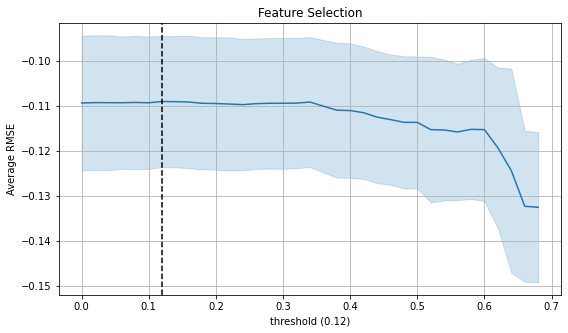

CPU times: user 9min 38s, sys: 7min 59s, total: 17min 37s
Wall time: 4min 35s


In [13]:
%%time

# Define pipeline
estimator = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', RobustScaler()),  
    ('selector', CorrelatedClusters(verbose = False)),
    ('model', RidgeCV(alphas = np.logspace(-1,2,200)))
])

# Parameter Grid
param_grid = {
    'selector__threshold': np.arange(0.0, 0.7, 0.02),
}

# GridSearch
clf = GridSearchCV(
    estimator = estimator,
    param_grid = param_grid,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
)

# Data structure of cv scores
clf.fit(train, target)
plot_gridcv_results(clf, 'threshold')

Created 201 clusters out of 238 features


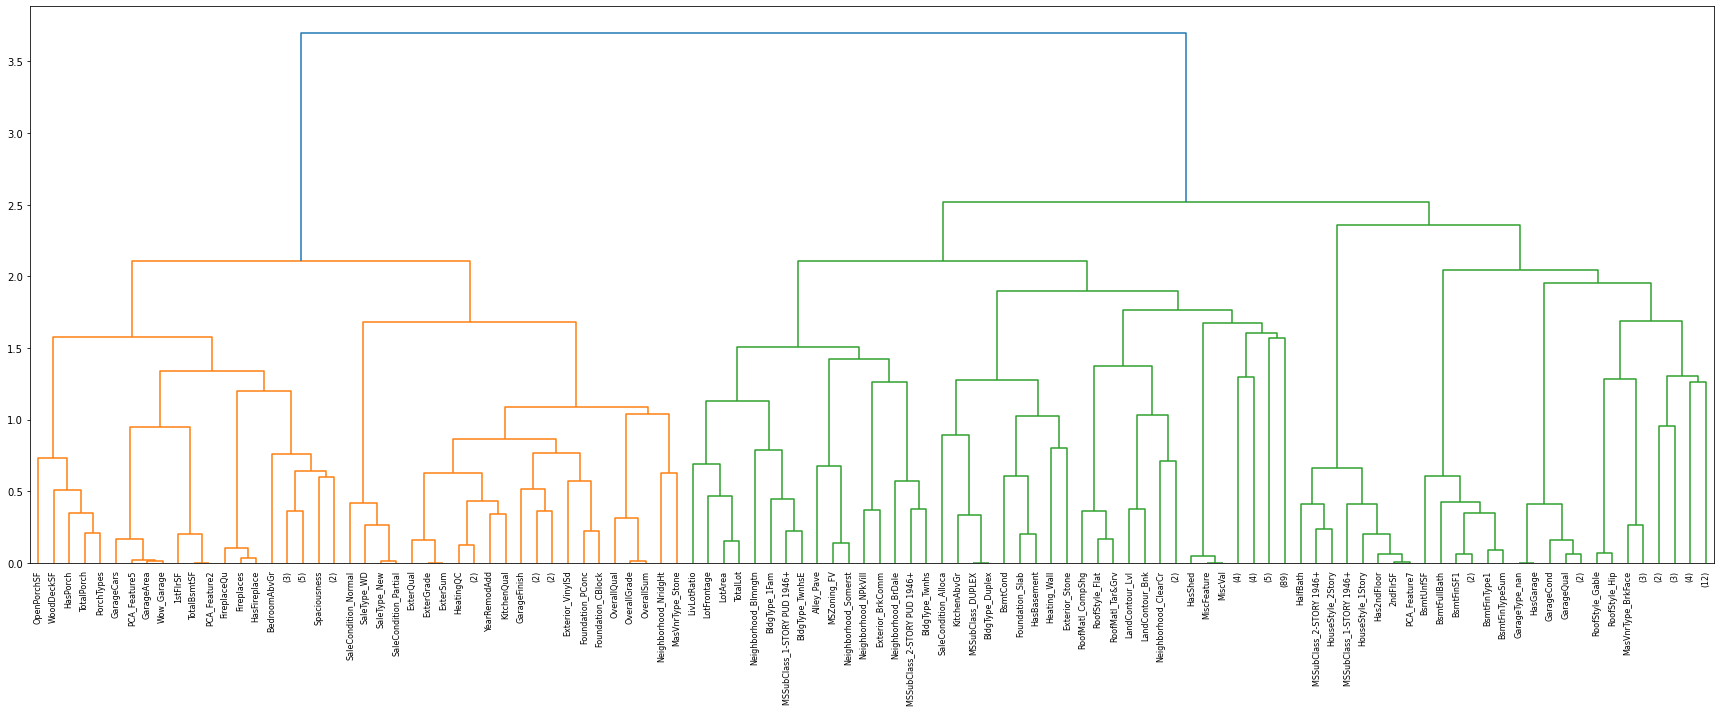

In [14]:
# Remaining features
clustering = CorrelatedClusters(threshold = clf.best_params_['selector__threshold'])
clustering.fit(X = train, y = target)
features = clustering.get_feature_names_out(test.columns)
clusters = clustering.get_clusters(test.columns)

# Fit model with remaining features 
scores = cross_validate(
    estimator = pipeline,
    X = train[features],
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Dendrogram
clustering.plot_dendrogram(train.columns)

In [15]:
# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['cluster_ridge'] += estimator.predict(test[features]) / NUM_FOLDS
    print(f'Fold {fold}:', round(-score,6), f'using {len(features)} columns.')
    cv_scores['cluster_ridge'].append(score)
cv_scores['cluster_ridge'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])


print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.089029 using 201 columns.
Fold 1: 0.116222 using 201 columns.
Fold 2: 0.124516 using 201 columns.
Fold 3: 0.132957 using 201 columns.
Fold 4: 0.097868 using 201 columns.
Fold 5: 0.119271 using 201 columns.
Fold 6: 0.09354 using 201 columns.
Fold 7: 0.107285 using 201 columns.
Fold 8: 0.113285 using 201 columns.
Fold 9: 0.123469 using 201 columns.
Fold 10: 0.09825 using 201 columns.
Fold 11: 0.093164 using 201 columns.

Best    (RSME): 0.089029
Median  (RSME): 0.109071
Average (RSME): 0.110285
Worst   (RSME): 0.132957


### 4.1.2. Gradient Boosting

The gradient boosting model appears to benefit slightly from clustering features

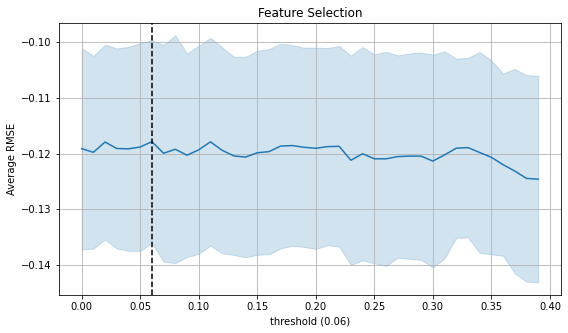

CPU times: user 11min 10s, sys: 2min 58s, total: 14min 8s
Wall time: 9min 16s


In [16]:
%%time

# Define pipeline
estimator = Pipeline([
    ('imputer', SimpleImputer()), 
    ('selector', CorrelatedClusters(verbose = False)),
    ('model', GradientBoostingRegressor())
])

# Parameter Grid
param_grid = {
    'selector__threshold': np.arange(0.0, 0.4, 0.01),
}

# GridSearch
clf = GridSearchCV(
    estimator = estimator,
    param_grid = param_grid,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
)

# Data structure of cv scores
clf.fit(train, target)
plot_gridcv_results(clf, 'threshold')

Created 212 clusters out of 238 features


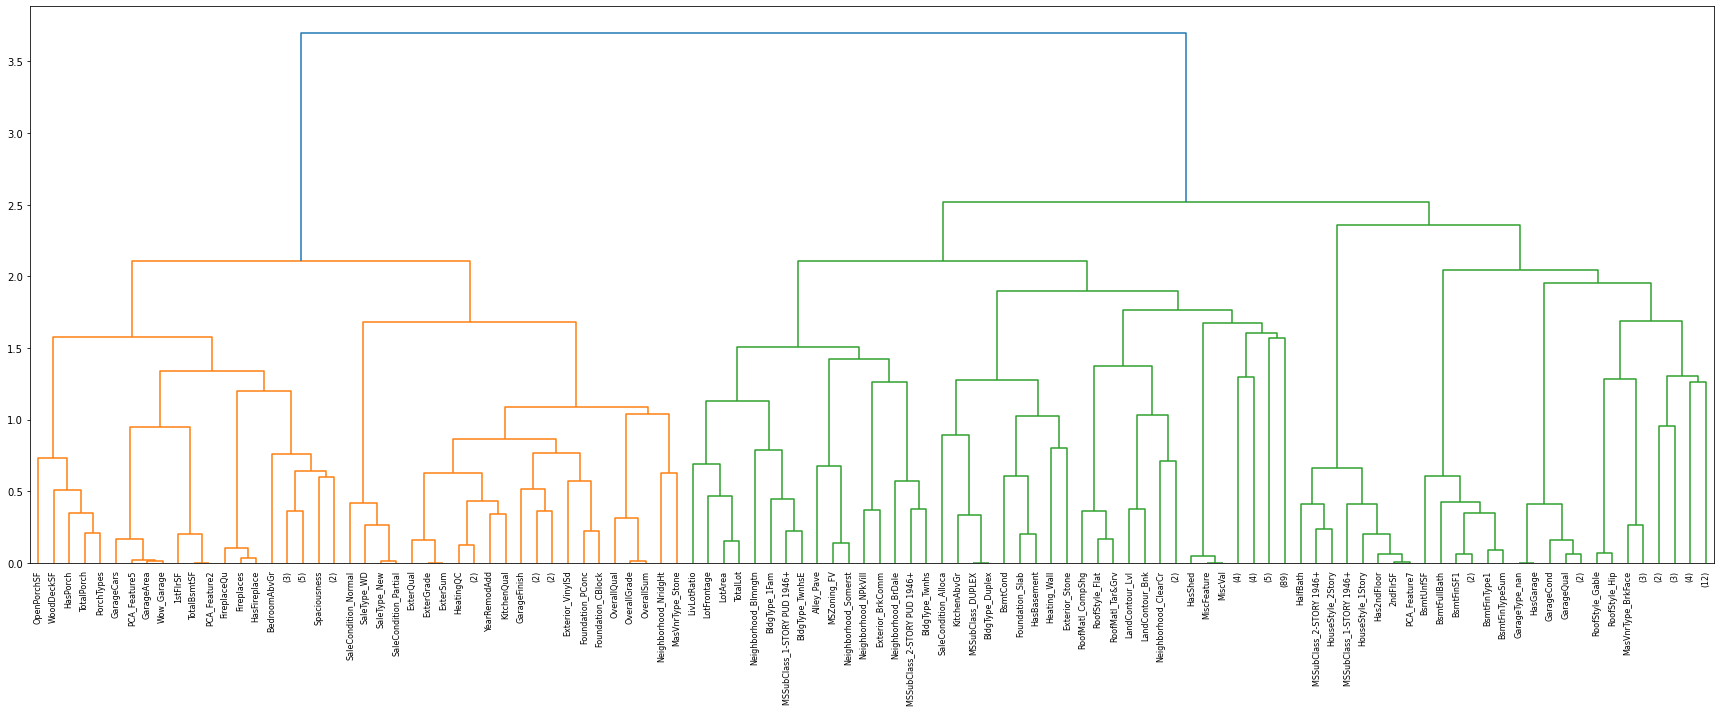

In [17]:
# Remaining features
clustering = CorrelatedClusters(threshold = clf.best_params_['selector__threshold'])
clustering.fit(X = train, y = target)
features = clustering.get_feature_names_out(test.columns)

# Fit model with remaining features 
scores = cross_validate(
    estimator = gb_pipeline,
    X = train[features],
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Dendrogram
clustering.plot_dendrogram(train.columns)

In [18]:
# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['cluster_boost'] += estimator.predict(test[features]) / NUM_FOLDS
    print(f'Fold {fold}:', round(-score,6), f'using {len(features)} columns.')
    cv_scores['cluster_boost'].append(score)
cv_scores['cluster_boost'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
  

print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.103499 using 212 columns.
Fold 1: 0.126309 using 212 columns.
Fold 2: 0.134292 using 212 columns.
Fold 3: 0.16563 using 212 columns.
Fold 4: 0.105218 using 212 columns.
Fold 5: 0.116747 using 212 columns.
Fold 6: 0.097006 using 212 columns.
Fold 7: 0.113601 using 212 columns.
Fold 8: 0.113872 using 212 columns.
Fold 9: 0.124612 using 212 columns.
Fold 10: 0.116834 using 212 columns.
Fold 11: 0.103645 using 212 columns.

Best    (RSME): 0.097006
Median  (RSME): 0.118439
Average (RSME): 0.11531
Worst   (RSME): 0.16563


## 4.2 Variance Inflation Factor

This methods was inspired by the following two notebooks:

1. [dealing-with-multicollinearity](https://www.kaggle.com/code/robertoruiz/dealing-with-multicollinearity) 
2. [sklearn-multicollinearity-class](https://www.kaggle.com/code/ffisegydd/sklearn-multicollinearity-class)

This works as follows, starting with the full set of features:

1. Calculate VIF for each feature
2. Remove the feature with the highest VIF
3. In the case of ties pick the feature least correlated with the target
4. Pick the feature set resulting in the best cross-validated score

We rewrite the function from the [statsmodels](https://www.statsmodels.org/0.6.1/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html) library to use scikit-learn functions `LinearRegression()` and `r2_score` which results in a significant speedup. This is still a fairly slow method since it has to compute k least squares regressions for all k remaining features at each iteration.


In [19]:
# Variance inflation factor
def variance_inflation(X):
    k_vars = X.shape[1]
    vif = np.zeros(k_vars)
    for idx in range(k_vars):
        mask = np.arange(k_vars) != idx
        preds = LinearRegression().fit(X[:, mask], X[:, idx]).predict(X[:, mask])
        vif[idx] = 1. / (1. - r2_score(X[:, idx], preds))
    return vif

# Feature selection using VIF
class VIFSelector(BaseEstimator, SelectorMixin):
    
    def __init__(self, estimator, threshold =  100 if DEBUG else 10, cv = 5):
        self.threshold = threshold
        self.cv = cv
        self.estimator = estimator
        
    def fit(self, X, y):

        temp = pd.DataFrame(
            RobustScaler().fit_transform(
                SimpleImputer().fit_transform(X)
            )
        ) 
        dist = {ft: 1 - abs(val) for val, ft in  zip(r_regression(temp, y), temp.columns)}
        cols = set(temp.columns)
        self.scores_ = list()
        self.n_vars_ = list()
        self.heap_ = list()
        columns = dict()
        while True:
            max_vif, _, col = max(zip(variance_inflation(temp[cols].values),[dist[x] for x in cols], cols))
            if max_vif < self.threshold: break
            cols.remove(col)
            n_vars = len(cols)
            columns[n_vars] = set(cols)
            cv_dict = cross_validate(
                estimator = self.estimator,
                X = temp[cols],
                y = y,
                scoring = 'neg_root_mean_squared_error',
                cv = self.cv,
                n_jobs = -1,
            )
            heappush(self.heap_, (-np.mean(cv_dict['test_score']), n_vars))
            self.scores_.append(np.mean(cv_dict['test_score']))
            self.n_vars_.append(n_vars)
        self.best_score, self.best_n_vars = self.heap_[0]
        self.mask_ = np.asarray([(x in columns[self.best_n_vars]) for x in temp.columns])
        return self
    
    def _get_support_mask(self):
        return self.mask_
    
    def plot_scores(self):
            fig, ax = plt.subplots(figsize=(9,5))
            sns.lineplot(x = self.n_vars_, y = self.scores_, ax = ax)
            plt.title('Iterative Feature Elimination w/ VIF')
            plt.axvline(x = self.best_n_vars, color='k', linestyle='--')
            plt.ylabel('Average RMSE')
            plt.xlabel(f'Number of Features')
            plt.grid()
            plt.show()

### 4.2.1 Linear Model

This appears to slightly benefit the linear model.

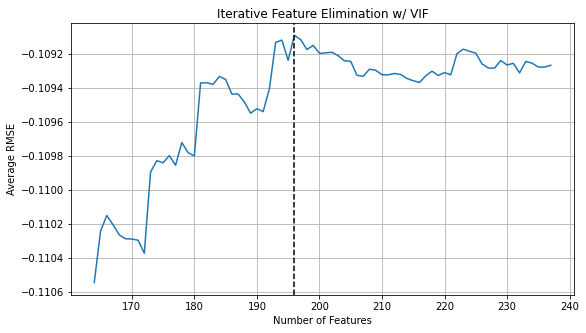

CPU times: user 2min 52s, sys: 7.17 s, total: 2min 59s
Wall time: 4min 6s


In [20]:
%%time

# Remaining features
selector = VIFSelector(estimator = RidgeCV(alphas = np.logspace(-1,2,200)), cv = skf)
selector.fit(X = train, y = target)
features = selector.get_feature_names_out(test.columns)

# Plot
selector.plot_scores()

In [21]:
# Fit model with remaining features 
scores = cross_validate(
    estimator = pipeline,
    X = train[features],
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['vif_ridge'] += estimator.predict(test[features]) / NUM_FOLDS
    print(f'Fold {fold}:', round(-score,6), f'using {len(features)} columns.')
    cv_scores['vif_ridge'].append(score)
cv_scores['vif_ridge'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
   

print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.088517 using 196 columns.
Fold 1: 0.115452 using 196 columns.
Fold 2: 0.125696 using 196 columns.
Fold 3: 0.132653 using 196 columns.
Fold 4: 0.096656 using 196 columns.
Fold 5: 0.117946 using 196 columns.
Fold 6: 0.092603 using 196 columns.
Fold 7: 0.108719 using 196 columns.
Fold 8: 0.113691 using 196 columns.
Fold 9: 0.123923 using 196 columns.
Fold 10: 0.101763 using 196 columns.
Fold 11: 0.091501 using 196 columns.

Best    (RSME): 0.088517
Median  (RSME): 0.109093
Average (RSME): 0.111205
Worst   (RSME): 0.132653


### 4.2.2 Gradient Boosting

This may result in modest improvement for the gradient boosting model.

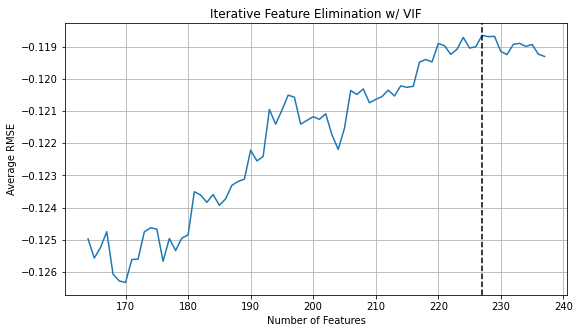

CPU times: user 2min 51s, sys: 6.97 s, total: 2min 58s
Wall time: 8min 34s


In [22]:
%%time

# Remaining features
selector = VIFSelector(estimator = GradientBoostingRegressor(), cv = skf)
selector.fit(X = train, y = target)
features = selector.get_feature_names_out(test.columns)

# Plot
selector.plot_scores()

In [23]:
# Fit model with remaining features 
scores = cross_validate(
    estimator = gb_pipeline,
    X = train[features],
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['vif_boost'] += estimator.predict(test[features]) / NUM_FOLDS
    print(f'Fold {fold}:', round(-score,6), f'using {len(features)} columns.')
    cv_scores['vif_boost'].append(score)
cv_scores['vif_boost'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 

print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.097425 using 227 columns.
Fold 1: 0.125667 using 227 columns.
Fold 2: 0.129581 using 227 columns.
Fold 3: 0.165938 using 227 columns.
Fold 4: 0.103237 using 227 columns.
Fold 5: 0.125344 using 227 columns.
Fold 6: 0.100518 using 227 columns.
Fold 7: 0.11691 using 227 columns.
Fold 8: 0.120478 using 227 columns.
Fold 9: 0.119889 using 227 columns.
Fold 10: 0.117408 using 227 columns.
Fold 11: 0.102307 using 227 columns.

Best    (RSME): 0.097425
Median  (RSME): 0.118725
Average (RSME): 0.118649
Worst   (RSME): 0.165938


# 5. Recursive Feature Elimination

This technique uses the built-in `.coef_` or `.feature_importance` attribute of our fitted models. I couldn't get good results with this method with either gradient boosting or the linear model.

In [24]:
%%time

# Each iteration remove 5 worst features by feature importance
selector = RFECV(
    gb_pipeline,
    step = 10,
    scoring = 'neg_root_mean_squared_error', 
    cv = skf, 
    n_jobs = -1,
    importance_getter = 'named_steps.model.feature_importances_'
)

# Remaining features
selector.fit(X = SimpleImputer().fit_transform(train), y = target)
features = selector.get_feature_names_out(train.columns)

# Fit model with remaining features 
scores = cross_validate(
    estimator = gb_pipeline,
    X = train[features],
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['rfecv_boost'] += estimator.predict(test[features]) / NUM_FOLDS
    print(f'Fold {fold}:', round(-score,6), f'using {len(features)} columns.')
    cv_scores['rfecv_boost'].append(score)
cv_scores['rfecv_boost'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 

print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.098936 using 108 columns.
Fold 1: 0.127089 using 108 columns.
Fold 2: 0.132829 using 108 columns.
Fold 3: 0.164908 using 108 columns.
Fold 4: 0.103904 using 108 columns.
Fold 5: 0.123673 using 108 columns.
Fold 6: 0.095636 using 108 columns.
Fold 7: 0.115546 using 108 columns.
Fold 8: 0.120608 using 108 columns.
Fold 9: 0.121885 using 108 columns.
Fold 10: 0.113688 using 108 columns.
Fold 11: 0.10187 using 108 columns.

Best    (RSME): 0.095636
Median  (RSME): 0.118381
Average (RSME): 0.118077
Worst   (RSME): 0.164908
CPU times: user 21.8 s, sys: 34 ms, total: 21.8 s
Wall time: 2min 23s


# 6. SelectKBest

In this section we consider methods using`SelectKBest` selector with the following scoring schemes:

1. Mutual Information
2. F-score

For each method, we vary the number of chosen features and pick the one which results in the best cross-validated scores.

## 6.1 Mutual Information - Linear Model

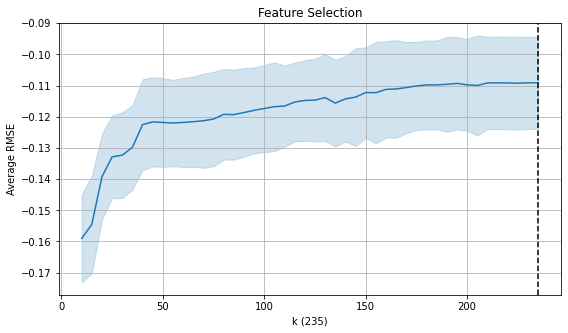

CPU times: user 7.13 s, sys: 1.35 s, total: 8.47 s
Wall time: 7min 59s


In [25]:
%%time

# Pipeline
estimator = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', RobustScaler()),
    ('selector', SelectKBest()),
    ('ridge', RidgeCV(alphas = np.logspace(-1,2,200)))
])

# Parameter Grid
param_grid = {
    'selector__score_func': [mutual_info_regression],
    'selector__k': np.arange(10, len(test.columns), 5)
}

# GridSearch
clf = GridSearchCV(
    estimator = estimator,
    param_grid = param_grid,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
)

# Data structure of cv scores
clf.fit(SimpleImputer().fit_transform(train), target)

# Plot scores
plot_gridcv_results(clf , 'k')

In [26]:
# Fit model with optimal parameters
scores = cross_validate(
    estimator = estimator.set_params(**clf.best_params_),
    X = train,
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['mi_ridge'] += estimator.predict(test) / NUM_FOLDS
    temp = estimator.named_steps.selector.get_feature_names_out(train.columns)
    print(f'Fold {fold}:', round(-score,6), f'using {len(temp)} columns.')
    cv_scores['mi_ridge'].append(score)
cv_scores['mi_ridge'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 
    
print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.088127 using 235 columns.
Fold 1: 0.115811 using 235 columns.
Fold 2: 0.124963 using 235 columns.
Fold 3: 0.134516 using 235 columns.
Fold 4: 0.098394 using 235 columns.
Fold 5: 0.118931 using 235 columns.
Fold 6: 0.092509 using 235 columns.
Fold 7: 0.108182 using 235 columns.
Fold 8: 0.114206 using 235 columns.
Fold 9: 0.123335 using 235 columns.
Fold 10: 0.10189 using 235 columns.
Fold 11: 0.091082 using 235 columns.

Best    (RSME): 0.088127
Median  (RSME): 0.109329
Average (RSME): 0.111194
Worst   (RSME): 0.134516


## 6.2 Mutual Information - Gradient Boosting

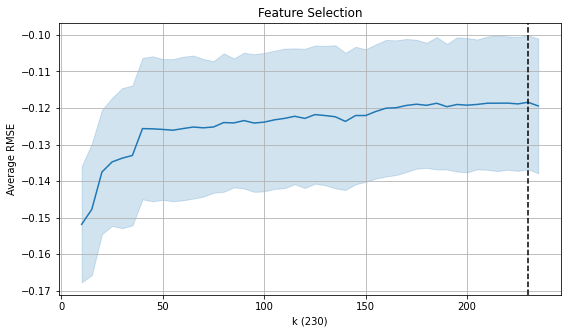

CPU times: user 7.7 s, sys: 366 ms, total: 8.06 s
Wall time: 11min 26s


In [27]:
%%time

# Pipeline
estimator = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', RobustScaler()),
    ('selector', SelectKBest()),
    ('model', GradientBoostingRegressor())
])

# Parameter Grid
param_grid = {
    'selector__score_func': [mutual_info_regression],
    'selector__k': np.arange(10, len(test.columns), 5)
}

# GridSearch
clf = GridSearchCV(
    estimator = estimator,
    param_grid = param_grid,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
)

# Data structure of cv scores
clf.fit(SimpleImputer().fit_transform(train), target)

# Plot scores
plot_gridcv_results(clf , 'k')

In [28]:
# Fit model with optimal parameters
scores = cross_validate(
    estimator = estimator.set_params(**clf.best_params_),
    X = train,
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['mi_boost'] += estimator.predict(test) / NUM_FOLDS
    temp = estimator.named_steps.selector.get_feature_names_out(train.columns)
    print(f'Fold {fold}:', round(-score,6), f'using {len(temp)} columns.')
    cv_scores['mi_boost'].append(score)
cv_scores['mi_boost'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 
    
print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.100332 using 230 columns.
Fold 1: 0.124532 using 230 columns.
Fold 2: 0.131278 using 230 columns.
Fold 3: 0.166507 using 230 columns.
Fold 4: 0.102796 using 230 columns.
Fold 5: 0.124152 using 230 columns.
Fold 6: 0.100951 using 230 columns.
Fold 7: 0.117154 using 230 columns.
Fold 8: 0.119438 using 230 columns.
Fold 9: 0.121924 using 230 columns.
Fold 10: 0.118137 using 230 columns.
Fold 11: 0.102821 using 230 columns.

Best    (RSME): 0.100332
Median  (RSME): 0.119169
Average (RSME): 0.118787
Worst   (RSME): 0.166507


## 6.3. F-score - Linear Model

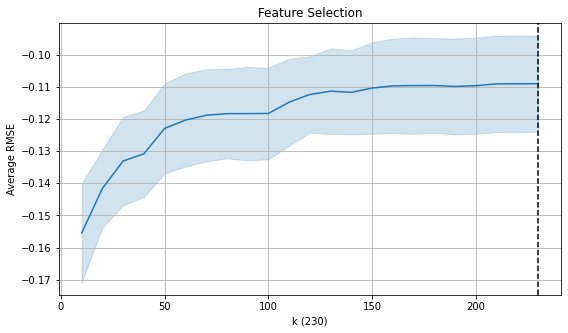

CPU times: user 3min 55s, sys: 3min 23s, total: 7min 19s
Wall time: 1min 52s


In [29]:
%%time

# Pipeline
estimator = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', RobustScaler()),
    ('selector', SelectKBest()),
    ('ridge', RidgeCV(alphas = np.logspace(-1,2,200)))
])

# Parameter Grid
param_grid = {
    'selector__score_func': [f_regression],
    'selector__k': np.arange(10, len(test.columns), 10)
}

# GridSearch
clf = GridSearchCV(
    estimator = estimator,
    param_grid = param_grid,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
)

# Data structure of cv scores
clf.fit(SimpleImputer().fit_transform(train), target)

# Plot scores
plot_gridcv_results(clf, 'k')

In [30]:
# Fit model with remaining features 
scores = cross_validate(
    estimator = estimator.set_params(**clf.best_params_),
    X = train,
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    return_estimator = True,
)

# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['f_ridge'] += estimator.predict(test) / NUM_FOLDS
    temp = estimator.named_steps.selector.get_feature_names_out(train.columns)
    print(f'Fold {fold}:', round(-score,6), f'using {len(temp)} columns.')
    cv_scores['f_ridge'].append(score)
cv_scores['f_ridge'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 
    
print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.088132 using 230 columns.
Fold 1: 0.115711 using 230 columns.
Fold 2: 0.124551 using 230 columns.
Fold 3: 0.134138 using 230 columns.
Fold 4: 0.098072 using 230 columns.
Fold 5: 0.11853 using 230 columns.
Fold 6: 0.092706 using 230 columns.
Fold 7: 0.108235 using 230 columns.
Fold 8: 0.11373 using 230 columns.
Fold 9: 0.12307 using 230 columns.
Fold 10: 0.101425 using 230 columns.
Fold 11: 0.090217 using 230 columns.

Best    (RSME): 0.088132
Median  (RSME): 0.109043
Average (RSME): 0.110983
Worst   (RSME): 0.134138


## 6.4. F-score - Gradient Boosting

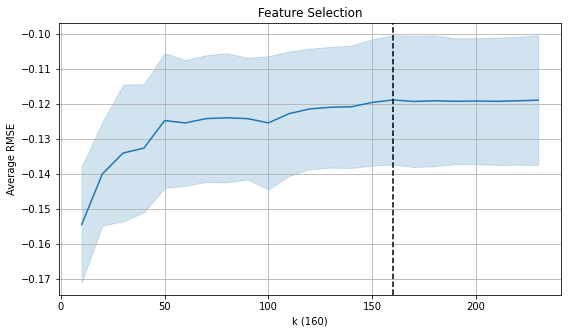

CPU times: user 6min 14s, sys: 59.9 s, total: 7min 14s
Wall time: 5min 34s


In [31]:
%%time

# Pipeline
estimator = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', RobustScaler()),
    ('selector', SelectKBest()),
    ('ridge', GradientBoostingRegressor())
])

# Parameter Grid
param_grid = {
    'selector__score_func': [f_regression],
    'selector__k': np.arange(10, len(test.columns), 10)
}

# GridSearch
clf = GridSearchCV(
    estimator = estimator,
    param_grid = param_grid,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
)

# Data structure of cv scores
clf.fit(SimpleImputer().fit_transform(train), target)

# Plot scores
plot_gridcv_results(clf, 'k')

In [32]:
# Fit model with remaining features 
scores = cross_validate(
    estimator = estimator.set_params(**clf.best_params_),
    X = train,
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    return_estimator = True,
)

# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['f_boost'] += estimator.predict(test) / NUM_FOLDS
    temp = estimator.named_steps.selector.get_feature_names_out(train.columns)
    print(f'Fold {fold}:', round(-score,6), f'using {len(temp)} columns.')
    cv_scores['f_boost'].append(score)
cv_scores['f_boost'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 
    
print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.097694 using 160 columns.
Fold 1: 0.123832 using 160 columns.
Fold 2: 0.130631 using 160 columns.
Fold 3: 0.165771 using 160 columns.
Fold 4: 0.102571 using 160 columns.
Fold 5: 0.126593 using 160 columns.
Fold 6: 0.099396 using 160 columns.
Fold 7: 0.119224 using 160 columns.
Fold 8: 0.122508 using 160 columns.
Fold 9: 0.122205 using 160 columns.
Fold 10: 0.114256 using 160 columns.
Fold 11: 0.103697 using 160 columns.

Best    (RSME): 0.097694
Median  (RSME): 0.119031
Average (RSME): 0.120714
Worst   (RSME): 0.165771


# 7. Permutation Importance

There is not a canonical way to use permutation importance for feature selection (e.g. within `SelectKBest`) so we have to do this manually. We accomplish this as follows:

1. Train several models using cross-validation
2. Evaluate permutation importance on each fold
3. Do the equivalent of `SelectKBest` using the permutation importance averaged over the folds

This method has to train a bunch of models to determine permutation importance so it may take a while to run.

In [33]:
class PermutationSelector(BaseEstimator, SelectorMixin):
    
    def __init__(self, estimator, cv = NUM_FOLDS, min_features = 20, step = 2):
        self.estimator = estimator
        self.cv = cv
        self.min_features = 20
        self.step = step
        
    def fit(self, X, y):
        
        train = pd.DataFrame(X)
        target = pd.Series(y)
        
        # Fit models to be used for perm importance
        scores = cross_validate(
            estimator = self.estimator,
            X = train,
            y = target,
            scoring = 'neg_root_mean_squared_error',
            cv = self.cv,
            return_estimator = True,
        )
        
        # Use fitted estimators to calculate permutation importance
        pi_scores = pd.Series(np.zeros(len(train.columns)), index = train.columns)
        for fold, (model, (train_idx, valid_idx)) in enumerate(zip(scores['estimator'], check_cv(self.cv).split(X))):
            pi_scores += permutation_importance(
                estimator = model, 
                X = train.loc[valid_idx],
                y = target.loc[valid_idx],
                scoring = 'neg_root_mean_squared_error',
                random_state = RANDOM_SEED,
                n_jobs = -1,
            )['importances_mean']

        # Data structure of cv scores
        self.num_features_ = list()
        self.scores_ = list()

        sorted_pi = pi_scores.sort_values(ascending = False)
        # Manual SelectKBest for k = 10, 20,...,
        for k in range(10, len(train.columns), self.step):
            
            features = list(sorted_pi.index[:k])
            # Fit models to be used for perm importance
            scores = cross_validate(
                estimator = self.estimator,
                X = train[features],
                y = target,
                scoring = 'neg_root_mean_squared_error',
                cv = self.cv,
                return_estimator = True,
            )
            self.num_features_.append(k)
            self.scores_.append(np.mean(scores['test_score']))
    
        self.best_score_, self.best_k_ = max(zip(self.scores_, self.num_features_))
        self.mask_ = np.asarray([(x in sorted_pi.index[:self.best_k_]) for x in train.columns])
    
    def _get_support_mask(self):
        return self.mask_
    
    def plot_scores(self):
            fig, ax = plt.subplots(figsize=(9,5))
            sns.lineplot(x = self.num_features_, y = self.scores_, ax = ax)
            plt.title('Feature Elimination w/ Permutation Importance')
            plt.axvline(x = self.best_k_, color='k', linestyle='--')
            plt.ylabel('Average RMSE')
            plt.xlabel(f'Number of Features')
            plt.grid()
            plt.show()
        

## 7.1 Linear Model

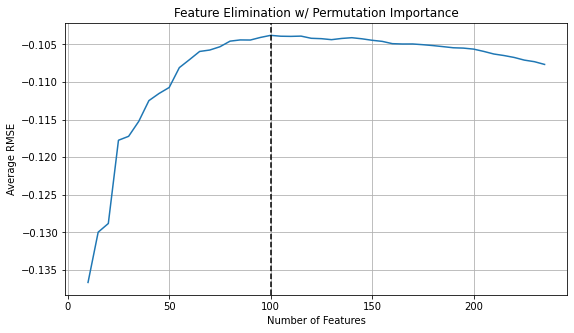

CPU times: user 7min 3s, sys: 5min 52s, total: 12min 55s
Wall time: 3min 50s


In [34]:
%%time

# Permutation Importance Selector
selector = PermutationSelector(
    pipeline, 
    cv = NUM_FOLDS, 
    min_features = 20, 
    step = 5
)

# Linear pipeline
sfs = selector.fit(X = train, y = target)
features = selector.get_feature_names_out(train.columns)

selector.plot_scores()

In [35]:
# Fit model with remaining features 
scores = cross_validate(
    estimator = pipeline,
    X = train[features],
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['perm_ridge'] += estimator.predict(test[features]) / NUM_FOLDS
    print(f'Fold {fold}:', round(-score,6), f'using {len(features)} columns.')
    cv_scores['perm_ridge'].append(score)
cv_scores['perm_ridge'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 

print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.085952 using 100 columns.
Fold 1: 0.105403 using 100 columns.
Fold 2: 0.117231 using 100 columns.
Fold 3: 0.12847 using 100 columns.
Fold 4: 0.095586 using 100 columns.
Fold 5: 0.108359 using 100 columns.
Fold 6: 0.094853 using 100 columns.
Fold 7: 0.107194 using 100 columns.
Fold 8: 0.111948 using 100 columns.
Fold 9: 0.121388 using 100 columns.
Fold 10: 0.095104 using 100 columns.
Fold 11: 0.084917 using 100 columns.

Best    (RSME): 0.084917
Median  (RSME): 0.1047
Average (RSME): 0.106299
Worst   (RSME): 0.12847


## 7.2 Gradient Boosting

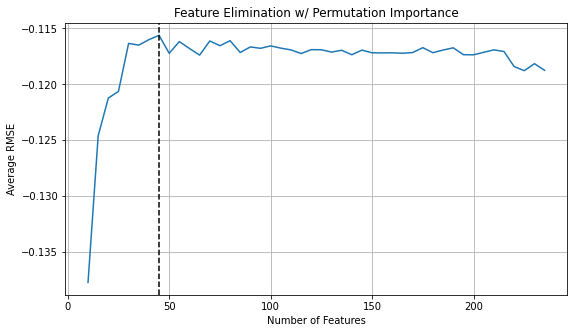

CPU times: user 9min 59s, sys: 668 ms, total: 9min 59s
Wall time: 10min 24s


In [36]:
%%time

# Permutation Importance Selector
selector = PermutationSelector(
    gb_pipeline, 
    cv = NUM_FOLDS, 
    min_features = 20, 
    step = 5
)

# Linear pipeline
sfs = selector.fit(X = train, y = target)
features = selector.get_feature_names_out(train.columns)

selector.plot_scores()

In [37]:
# Fit model with remaining features 
scores = cross_validate(
    estimator = gb_pipeline,
    X = train[features],
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['perm_boost'] += estimator.predict(test[features]) / NUM_FOLDS
    print(f'Fold {fold}:', round(-score,6), f'using {len(features)} columns.')
    cv_scores['perm_boost'].append(score)
cv_scores['perm_boost'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])
 

print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.097548 using 45 columns.
Fold 1: 0.126662 using 45 columns.
Fold 2: 0.136459 using 45 columns.
Fold 3: 0.161832 using 45 columns.
Fold 4: 0.105945 using 45 columns.
Fold 5: 0.124191 using 45 columns.
Fold 6: 0.096993 using 45 columns.
Fold 7: 0.11673 using 45 columns.
Fold 8: 0.113678 using 45 columns.
Fold 9: 0.11931 using 45 columns.
Fold 10: 0.116158 using 45 columns.
Fold 11: 0.09973 using 45 columns.

Best    (RSME): 0.096993
Median  (RSME): 0.117936
Average (RSME): 0.116444
Worst   (RSME): 0.161832


# 8. Sequential Feature Selection

We use an extended version of the scikit-learn SequentialFeatureSelector. Forward SFS is a greedy algorithm which adds the feature which results in the greatest cv score improvement at each iteration. To speed up the algorithm and hopefully give better results we group certain features together based on clustering and categories using the `feature_group` option.

## 8.1. SFS - Clusters

We consider highly correlated features together using the best clustering we found earlier (using the `CorrelatedClusters` class). This algorithm gives good results but runs very slowly.

In [38]:
%%time 

# Define sequential feature selector
selector = SequentialFeatureSelector(
    pipeline, 
    k_features = 2 if DEBUG else 'parsimonious',
    scoring = 'neg_root_mean_squared_error', 
    cv = skf, 
    feature_groups = clusters,
    n_jobs = -1,
)

# Linear pipeline
sfs = selector.fit(X = train, y = target)
features = list(selector.k_feature_names_)

# Fit model with best found features 
scores = cross_validate(
    estimator = pipeline,
    X = train[features],
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['sfs_clusters'] += estimator.predict(test[features]) / NUM_FOLDS
    print(f'Fold {fold}:', round(-score,6), f'using {len(features)} columns.')
    cv_scores['sfs_clusters'].append(score)
cv_scores['sfs_clusters'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])

print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.085019 using 61 columns.
Fold 1: 0.107067 using 61 columns.
Fold 2: 0.117878 using 61 columns.
Fold 3: 0.128556 using 61 columns.
Fold 4: 0.095764 using 61 columns.
Fold 5: 0.115267 using 61 columns.
Fold 6: 0.089819 using 61 columns.
Fold 7: 0.107374 using 61 columns.
Fold 8: 0.10952 using 61 columns.
Fold 9: 0.11327 using 61 columns.
Fold 10: 0.096842 using 61 columns.
Fold 11: 0.08646 using 61 columns.

Best    (RSME): 0.085019
Median  (RSME): 0.104403
Average (RSME): 0.10722
Worst   (RSME): 0.128556
CPU times: user 14min 44s, sys: 10.2 s, total: 14min 54s
Wall time: 3h 53min 51s


## 8.2 Feature Groups - Categories

In this section, we group the one-hot encoded features together which should reduce the dimensionality significantly.

In [39]:
%%time 

# Define groups (group one-hot encoded things together)
category_cols += ['Condition', 'Exterior']
groups = [[x for x in train.columns if x.startswith(y)] for y in category_cols]
groups += [[x] for x in train.columns if x not in set(chain.from_iterable(groups))]

# Define sequential feature selector
selector = SequentialFeatureSelector(
    pipeline, 
    k_features = 2 if DEBUG else 'parsimonious',
    scoring = 'neg_root_mean_squared_error', 
    cv = skf, 
    feature_groups = groups,
    n_jobs = -1,
)

# Linear pipeline
sfs = selector.fit(X = train, y = target)
features = list(selector.k_feature_names_)

# Fit model with best found features 
scores = cross_validate(
    estimator = pipeline,
    X = train[features],
    y = target,
    scoring = 'neg_root_mean_squared_error',
    cv = skf,
    n_jobs = -1,
    return_estimator = True,
)

# Make predictions
for fold, (score, estimator) in enumerate(zip(scores['test_score'], scores['estimator'])):
    preds['sfs_categories'] += estimator.predict(test[features]) / NUM_FOLDS
    print(f'Fold {fold}:', round(-score,6), f'using {len(features)} columns.')
    cv_scores['sfs_categories'].append(score)
cv_scores['sfs_categories'].extend([np.mean(scores['test_score']),np.median(scores['test_score'])])

print('\nBest    (RSME):', round(-np.max(scores['test_score']), 6))
print('Median  (RSME):', round(-np.mean(scores['test_score']), 6))
print('Average (RSME):', round(-np.median(scores['test_score']), 6))
print('Worst   (RSME):', round(-np.min(scores['test_score']), 6))

Fold 0: 0.084916 using 108 columns.
Fold 1: 0.110261 using 108 columns.
Fold 2: 0.123385 using 108 columns.
Fold 3: 0.131024 using 108 columns.
Fold 4: 0.09525 using 108 columns.
Fold 5: 0.115437 using 108 columns.
Fold 6: 0.089705 using 108 columns.
Fold 7: 0.108125 using 108 columns.
Fold 8: 0.110844 using 108 columns.
Fold 9: 0.120806 using 108 columns.
Fold 10: 0.100046 using 108 columns.
Fold 11: 0.089518 using 108 columns.

Best    (RSME): 0.084916
Median  (RSME): 0.10661
Average (RSME): 0.109193
Worst   (RSME): 0.131024
CPU times: user 2min 46s, sys: 3.43 s, total: 2min 49s
Wall time: 1h 27min 54s


# 9. Summary

In [40]:
temp = pd.DataFrame(cv_scores)
temp.set_index('Scheme', inplace = True)
temp = temp.T
temp.sort_values('Average', ascending = False)

Scheme,Split 0,Split 1,Split 2,Split 3,Split 4,Split 5,Split 6,Split 7,Split 8,Split 9,Split 10,Split 11,Average,Median
sfs_clusters,-0.085019,-0.107067,-0.117878,-0.128556,-0.095764,-0.115267,-0.089819,-0.107374,-0.109520,-0.113270,-0.096842,-0.086460,-0.104403,-0.107220
perm_ridge,-0.085952,-0.105403,-0.117231,-0.128470,-0.095586,-0.108359,-0.094853,-0.107194,-0.111948,-0.121388,-0.095104,-0.084917,-0.104700,-0.106299
sfs_categories,-0.084916,-0.110261,-0.123385,-0.131024,-0.095250,-0.115437,-0.089705,-0.108125,-0.110844,-0.120806,-0.100046,-0.089518,-0.106610,-0.109193
lassolars,-0.087639,-0.110713,-0.119160,-0.136040,-0.101547,-0.116967,-0.096331,-0.109310,-0.116754,-0.119256,-0.102241,-0.088807,-0.108730,-0.110011
f_ridge,-0.088132,-0.115711,-0.124551,-0.134138,-0.098072,-0.118530,-0.092706,-0.108235,-0.113730,-0.123070,-0.101425,-0.090217,-0.109043,-0.110983
cluster_ridge,-0.089029,-0.116222,-0.124516,-0.132957,-0.097868,-0.119271,-0.093540,-0.107285,-0.113285,-0.123469,-0.098250,-0.093164,-0.109071,-0.110285
lasso,-0.089244,-0.110421,-0.119920,-0.133918,-0.100407,-0.117805,-0.096564,-0.108237,-0.117479,-0.120934,-0.102225,-0.091926,-0.109090,-0.109329
elasticnet,-0.089244,-0.110421,-0.119920,-0.133918,-0.100407,-0.117805,-0.096564,-0.108237,-0.117479,-0.120934,-0.102225,-0.091926,-0.109090,-0.109329
vif_ridge,-0.088517,-0.115452,-0.125696,-0.132653,-0.096656,-0.117946,-0.092603,-0.108719,-0.113691,-0.123923,-0.101763,-0.091501,-0.109093,-0.111205
ridge,-0.088229,-0.115907,-0.125039,-0.134256,-0.098140,-0.119400,-0.092403,-0.108392,-0.113688,-0.122726,-0.101710,-0.091218,-0.109259,-0.111040


# 10. Submissions

Finally, we used our saved predictions to make submissions.

In [41]:
for key in preds.keys():

    # Create submission for each method/model
    submission['SalePrice'] = np.expm1(preds[key])
    submission.to_csv(f'{key}_submission.csv', index = False)

Thank you for reading, I hope you found this useful.